# ML Operations Assignment: Feature Store with ML Pipeline

### Jason Clark

**Note:** Generative AI Tools were used for coding and formatting assistance.

## Tech Stack:
- MLOps Platform - MLFlow
- Feature Store - FEAST
- Carbon Emissions - CodeCarbon

---

## Setup and Installation

In [64]:
# Install required packages (run once)
!pip install feast mlflow pandas numpy scikit-learn matplotlib seaborn pyarrow joblib codecarbon --quiet


[notice] A new release of pip is available: 25.3 -> 26.0.1
[notice] To update, run: pip install --upgrade pip


In [65]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
from sklearn.preprocessing import StandardScaler, LabelEncoder
from datetime import datetime, timedelta
import warnings
import os
import shutil
import json
import joblib

# MLflow imports
import mlflow
import mlflow.sklearn
from mlflow.models.signature import infer_signature
from mlflow.tracking import MlflowClient

warnings.filterwarnings('ignore')
RANDOM_STATE = 42
np.random.seed(RANDOM_STATE)

print(f"MLflow version: {mlflow.__version__}")
print("All imports successful!")

MLflow version: 3.11.1
All imports successful!


---
# Part 1: Load and Explore the Data

In [66]:
# Load raw data
df_raw = pd.read_csv('athletes.csv')
print(f"Raw data shape: {df_raw.shape}")
print(f"Columns: {df_raw.columns.tolist()}")

Raw data shape: (423006, 27)
Columns: ['athlete_id', 'name', 'region', 'team', 'affiliate', 'gender', 'age', 'height', 'weight', 'fran', 'helen', 'grace', 'filthy50', 'fgonebad', 'run400', 'run5k', 'candj', 'snatch', 'deadlift', 'backsq', 'pullups', 'eat', 'train', 'background', 'experience', 'schedule', 'howlong']


In [67]:
# Preview data
df_raw.head(10)

,athlete_id,name,region,team,affiliate,gender,age,height,weight,fran,...,snatch,deadlift,backsq,pullups,eat,train,background,experience,schedule,howlong
0,2554.0,Pj Ablang,South West,Double Edge,Double Edge CrossFit,Male,24.0,70.0,166.0,NaN,...,NaN,400.0,305.0,NaN,NaN,I workout mostly at a CrossFit Affiliate|I hav...,I played youth or high school level sports|I r...,I began CrossFit with a coach (e.g. at an affi...,I do multiple workouts in a day 2x a week|,4+ years|
1,3517.0,Derek Abdella,NaN,NaN,NaN,Male,42.0,70.0,190.0,NaN,...,NaN,NaN,NaN,NaN,NaN,I have a coach who determines my programming|I...,I played youth or high school level sports|,I began CrossFit with a coach (e.g. at an affi...,I do multiple workouts in a day 2x a week|,4+ years|
2,4691.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3,5164.0,Abo Brandon,Southern California,LAX CrossFit,LAX CrossFit,Male,40.0,67.0,NaN,211.0,...,200.0,375.0,325.0,25.0,I eat 1-3 full cheat meals per week|,I workout mostly at a CrossFit Affiliate|I hav...,I played youth or high school level sports|,I began CrossFit by trying it alone (without a...,I usually only do 1 workout a day|,4+ years|
4,5286.0,Bryce Abbey,NaN,NaN,NaN,Male,32.0,65.0,149.0,206.0,...,150.0,NaN,325.0,50.0,I eat quality foods but don't measure the amount|,I workout mostly at a CrossFit Affiliate|I inc...,I played college sports|,I began CrossFit by trying it alone (without a...,I usually only do 1 workout a day|I strictly s...,1-2 years|
5,6491.0,Jason Abney,NaN,NaN,NaN,Male,37.0,73.0,230.0,NaN,...,200.0,435.0,414.0,NaN,I eat strict Paleo|,I workout mostly at a CrossFit Affiliate|I rec...,I played youth or high school level sports|,I began CrossFit by trying it alone (without a...,I usually only do 1 workout a day|I typically ...,4+ years|
6,6610.0,Anthony Abeel,South Central,Get Lifted,Get Lifted CrossFit,Male,21.0,72.0,175.0,NaN,...,0.0,0.0,0.0,0.0,I eat quality foods but don't measure the amou...,I workout mostly at a CrossFit Affiliate|I hav...,I have no athletic background besides CrossFit|,I began CrossFit with a coach (e.g. at an affi...,I do multiple workouts in a day 3+ times a wee...,2-4 years|
7,7268.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
8,7463.0,Tye Abell,NaN,NaN,NaN,Male,30.0,72.0,175.0,NaN,...,0.0,0.0,0.0,0.0,NaN,NaN,NaN,NaN,NaN,NaN
9,8242.0,Ryan Achilles,NaN,NaN,NaN,Male,40.0,68.0,177.0,205.0,...,185.0,365.0,365.0,NaN,I eat quality foods but don't measure the amount|,I workout mostly at a CrossFit Affiliate|I rec...,I played youth or high school level sports|I p...,I began CrossFit by trying it alone (without a...,I usually only do 1 workout a day|I typically ...,2-4 years|


In [68]:
# Basic statistics
df_raw.describe()

,athlete_id,age,height,weight,fran,helen,grace,filthy50,fgonebad,run400,run5k,candj,snatch,deadlift,backsq,pullups
count,423003.000000,331110.000000,1.598690e+05,229890.000000,5.542600e+04,3.027900e+04,4.074500e+04,1.935900e+04,2.973800e+04,2.224600e+04,3.609700e+04,1.044350e+05,9.728000e+04,1.153230e+05,1.105170e+05,5.060800e+04
mean,292748.166538,32.516750,1.206217e+02,170.896137,9.886691e+02,1.207950e+03,5.766025e+02,2.127863e+03,1.472252e+03,5.241279e+02,3.411464e+03,2.709107e+02,2.424957e+02,6.970503e+02,5.852109e+02,4.269613e+04
std,184969.660327,7.730671,2.097995e+04,58.379799,7.200430e+04,6.824091e+04,4.891145e+04,6.055021e+04,9.762688e+04,5.628804e+04,1.251980e+05,2.596882e+04,2.708942e+04,5.523235e+04,5.052976e+04,9.546078e+06
min,82.000000,13.000000,0.000000e+00,1.000000,1.000000e+00,1.000000e+00,-6.000000e+01,1.000000e+00,0.000000e+00,1.000000e+00,1.000000e+00,-4.500000e+01,0.000000e+00,-5.000000e+02,-7.000000e+00,-6.000000e+00
25%,135091.500000,27.000000,6.600000e+01,145.000000,2.150000e+02,5.250000e+02,1.490000e+02,1.308000e+03,2.400000e+02,6.200000e+01,1.242000e+03,1.400000e+02,1.050000e+02,2.550000e+02,2.050000e+02,1.500000e+01
50%,275839.000000,31.000000,6.900000e+01,170.000000,2.900000e+02,5.950000e+02,1.930000e+02,1.550000e+03,2.940000e+02,7.100000e+01,1.380000e+03,1.950000e+02,1.450000e+02,3.450000e+02,2.750000e+02,2.700000e+01
75%,473188.000000,37.000000,7.200000e+01,192.000000,3.920000e+02,6.940000e+02,2.620000e+02,1.809000e+03,3.360000e+02,8.400000e+01,1.560000e+03,2.350000e+02,1.850000e+02,4.150000e+02,3.350000e+02,3.900000e+01
max,633083.000000,125.000000,8.388607e+06,20175.000000,8.388607e+06,8.388607e+06,8.388607e+06,8.388607e+06,8.388607e+06,8.388607e+06,8.388607e+06,8.388607e+06,8.388607e+06,8.388607e+06,8.388607e+06,2.147484e+09


In [69]:
# Check missing values
missing = df_raw.isnull().sum()
missing_pct = (missing / len(df_raw) * 100).round(2)
missing_df = pd.DataFrame({'Missing': missing, 'Percent': missing_pct})
print("Missing Values:")
print(missing_df[missing_df['Missing'] > 0].sort_values('Percent', ascending=False))

Missing Values:
            Missing  Percent
filthy50     403647    95.42
run400       400760    94.74
fgonebad     393268    92.97
helen        392727    92.84
run5k        386909    91.47
grace        382261    90.37
pullups      372398    88.04
fran         367580    86.90
eat          329074    77.79
snatch       325726    77.00
schedule     325131    76.86
background   324061    76.61
candj        318571    75.31
experience   318070    75.19
train        317175    74.98
howlong      313800    74.18
backsq       312489    73.87
deadlift     307683    72.74
team         267846    63.32
height       263137    62.21
weight       193116    45.65
affiliate    181090    42.81
region       171744    40.60
name          91896    21.72
age           91896    21.72
gender        91896    21.72
athlete_id        3     0.00


---
# Part 2: Data Cleaning

In [70]:
def clean_athletes_data(data):
    """
    Clean the athletes dataset.
    Target variable: total_lift (sum of deadlift, candj, snatch, backsq)
    """
    df = data.copy()
    
    # Keep only rows with valid lift data (our target components)
    lift_cols = ['deadlift', 'candj', 'snatch', 'backsq']
    df = df.dropna(subset=lift_cols)
    
    # Remove rows with zero or negative lifts
    for col in lift_cols:
        df = df[df[col] > 0]
    
    # Keep essential features and drop identifiers/text columns
    cols_to_drop = ['athlete_id', 'name', 'team', 'affiliate', 
                    'eat', 'train', 'background', 'experience', 'schedule', 'howlong',
                    'fran', 'helen', 'grace', 'filthy50', 'fgonebad', 'run400', 'run5k', 'pullups']
    cols_to_drop = [c for c in cols_to_drop if c in df.columns]
    df = df.drop(columns=cols_to_drop)
    
    # Remove invalid gender
    df = df[df['gender'].isin(['Male', 'Female'])]
    
    # Drop rows with missing values in remaining columns
    df = df.dropna(subset=['age', 'height', 'weight', 'gender', 'region'])
    
    # Remove outliers
    df = df[(df['age'] >= 18) & (df['age'] <= 70)]
    df = df[(df['height'] >= 48) & (df['height'] <= 96)]  # 4ft to 8ft in inches
    df = df[(df['weight'] >= 80) & (df['weight'] <= 400)]  # 80 to 400 lbs
    
    # Remove extreme lift outliers (world record based)
    df = df[df['deadlift'] <= 1105]  # World record
    df = df[df['candj'] <= 500]
    df = df[df['snatch'] <= 496]
    df = df[df['backsq'] <= 1069]
    
    # Reset index
    df = df.reset_index(drop=True)
    
    return df

df_clean = clean_athletes_data(df_raw)
print(f"Cleaned data shape: {df_clean.shape}")
print(f"Rows removed: {len(df_raw) - len(df_clean)} ({((len(df_raw) - len(df_clean)) / len(df_raw) * 100):.1f}%)")

Cleaned data shape: (53110, 9)
Rows removed: 369896 (87.4%)


In [71]:
# View cleaned data
df_clean.head()

,region,gender,age,height,weight,candj,snatch,deadlift,backsq
0,Central East,Male,30.0,70.0,155.0,175.0,95.0,335.0,235.0
1,North East,Male,42.0,72.0,210.0,325.0,235.0,515.0,505.0
2,Southern California,Male,30.0,71.0,200.0,235.0,175.0,385.0,315.0
3,Africa,Male,28.0,70.0,176.0,187.0,134.0,335.0,254.0
4,North East,Male,35.0,68.0,225.0,285.0,205.0,440.0,405.0


In [72]:
df_clean.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 53110 entries, 0 to 53109
Data columns (total 9 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   region    53110 non-null  object 
 1   gender    53110 non-null  object 
 2   age       53110 non-null  float64
 3   height    53110 non-null  float64
 4   weight    53110 non-null  float64
 5   candj     53110 non-null  float64
 6   snatch    53110 non-null  float64
 7   deadlift  53110 non-null  float64
 8   backsq    53110 non-null  float64
dtypes: float64(7), object(2)
memory usage: 3.6+ MB


---
# Part 3: Feature Store Setup with Feast

I created two versions of the features:
- **V1 (Basic Features)**: Raw numeric features + encoded categoricals
- **V2 (Engineered Features)**: V1 + BMI, age groups, strength ratios, polynomial features

In [73]:
# Create feature store directory
FEATURE_STORE_DIR = 'feature_store'
DATA_DIR = os.path.join(FEATURE_STORE_DIR, 'data')

# Clean up and recreate
if os.path.exists(FEATURE_STORE_DIR):
    shutil.rmtree(FEATURE_STORE_DIR)
os.makedirs(DATA_DIR, exist_ok=True)
print(f"Created feature store directory: {FEATURE_STORE_DIR}")

Created feature store directory: feature_store


## 3.1 Create Feature Version 1 (Basic Features)

In [74]:
def create_features_v1(df):
    """
    Feature Version 1: Basic features
    - Numeric: age, height, weight
    - Encoded: gender, region
    - Target: total_lift
    """
    features = df.copy()
    
    # Create target variable
    features['total_lift'] = features['deadlift'] + features['candj'] + features['snatch'] + features['backsq']
    
    # Encode categorical variables
    le_gender = LabelEncoder()
    le_region = LabelEncoder()
    features['gender_encoded'] = le_gender.fit_transform(features['gender'])
    features['region_encoded'] = le_region.fit_transform(features['region'])
    
    # Select features for V1
    feature_cols_v1 = ['age', 'height', 'weight', 'gender_encoded', 'region_encoded']
    
    # Create feature dataframe
    features_v1 = features[feature_cols_v1 + ['total_lift']].copy()
    
    # Add entity ID and timestamp (required for Feast)
    features_v1['athlete_entity_id'] = range(len(features_v1))
    features_v1['event_timestamp'] = pd.to_datetime(datetime.now() - timedelta(days=1))
    
    return features_v1, feature_cols_v1

features_v1, feature_cols_v1 = create_features_v1(df_clean)
print(f"Feature V1 shape: {features_v1.shape}")
print(f"V1 Features: {feature_cols_v1}")
features_v1.head()

Feature V1 shape: (53110, 8)
V1 Features: ['age', 'height', 'weight', 'gender_encoded', 'region_encoded']


,age,height,weight,gender_encoded,region_encoded,total_lift,athlete_entity_id,event_timestamp
0,30.0,70.0,155.0,1,5,840.0,0,2026-04-21 18:17:12.201697
1,42.0,72.0,210.0,1,10,1580.0,1,2026-04-21 18:17:12.201697
2,30.0,71.0,200.0,1,16,1110.0,2,2026-04-21 18:17:12.201697
3,28.0,70.0,176.0,1,0,910.0,3,2026-04-21 18:17:12.201697
4,35.0,68.0,225.0,1,10,1335.0,4,2026-04-21 18:17:12.201697


## 3.2 Create Feature Version 2 (Engineered Features)

In [75]:
def create_features_v2(df):
    """
    Feature Version 2: Engineered features
    - All V1 features
    - BMI (Body Mass Index)
    - Age groups (binned)
    - Strength-to-weight ratio
    - Polynomial features (age^2, weight^2)
    - Interaction features (age*weight)
    """
    features = df.copy()
    
    # Create target variable
    features['total_lift'] = features['deadlift'] + features['candj'] + features['snatch'] + features['backsq']
    
    # Encode categorical variables
    le_gender = LabelEncoder()
    le_region = LabelEncoder()
    features['gender_encoded'] = le_gender.fit_transform(features['gender'])
    features['region_encoded'] = le_region.fit_transform(features['region'])
    
    # V1 features
    # (already have: age, height, weight, gender_encoded, region_encoded)
    
    # NEW V2 Features:
    # 1. BMI (height is in inches, weight in lbs) -> BMI = (weight / height^2) * 703
    features['bmi'] = (features['weight'] / (features['height'] ** 2)) * 703
    
    # 2. Age groups (binned)
    features['age_group'] = pd.cut(features['age'], 
                                   bins=[0, 25, 35, 45, 55, 100], 
                                   labels=[0, 1, 2, 3, 4]).astype(int)
    
    # 3. Weight class
    features['weight_class'] = pd.cut(features['weight'],
                                      bins=[0, 150, 180, 210, 250, 500],
                                      labels=[0, 1, 2, 3, 4]).astype(int)
    
    # 4. Height-to-weight ratio
    features['height_weight_ratio'] = features['height'] / features['weight']
    
    # 5. Polynomial features
    features['age_squared'] = features['age'] ** 2
    features['weight_squared'] = features['weight'] ** 2
    
    # 6. Interaction features
    features['age_weight_interaction'] = features['age'] * features['weight']
    features['height_weight_interaction'] = features['height'] * features['weight']
    
    # 7. Normalized age (0-1 scale)
    features['age_normalized'] = (features['age'] - features['age'].min()) / (features['age'].max() - features['age'].min())
    
    # Select features for V2
    feature_cols_v2 = [
        # V1 features
        'age', 'height', 'weight', 'gender_encoded', 'region_encoded',
        # V2 new features
        'bmi', 'age_group', 'weight_class', 'height_weight_ratio',
        'age_squared', 'weight_squared', 
        'age_weight_interaction', 'height_weight_interaction',
        'age_normalized'
    ]
    
    # Create feature dataframe
    features_v2 = features[feature_cols_v2 + ['total_lift']].copy()
    
    # Add entity ID and timestamp (required for Feast)
    features_v2['athlete_entity_id'] = range(len(features_v2))
    features_v2['event_timestamp'] = pd.to_datetime(datetime.now())
    
    return features_v2, feature_cols_v2

features_v2, feature_cols_v2 = create_features_v2(df_clean)
print(f"Feature V2 shape: {features_v2.shape}")
print(f"V2 Features: {feature_cols_v2}")
print(f"\nNew features in V2: {set(feature_cols_v2) - set(feature_cols_v1)}")
features_v2.head()

Feature V2 shape: (53110, 17)
V2 Features: ['age', 'height', 'weight', 'gender_encoded', 'region_encoded', 'bmi', 'age_group', 'weight_class', 'height_weight_ratio', 'age_squared', 'weight_squared', 'age_weight_interaction', 'height_weight_interaction', 'age_normalized']

New features in V2: {'weight_class', 'age_squared', 'bmi', 'age_normalized', 'height_weight_ratio', 'age_group', 'height_weight_interaction', 'weight_squared', 'age_weight_interaction'}


,age,height,weight,gender_encoded,region_encoded,bmi,age_group,weight_class,height_weight_ratio,age_squared,weight_squared,age_weight_interaction,height_weight_interaction,age_normalized,total_lift,athlete_entity_id,event_timestamp
0,30.0,70.0,155.0,1,5,22.237755,1,1,0.451613,900.0,24025.0,4650.0,10850.0,0.315789,840.0,0,2026-04-22 18:17:12.384194
1,42.0,72.0,210.0,1,10,28.478009,2,2,0.342857,1764.0,44100.0,8820.0,15120.0,0.631579,1580.0,1,2026-04-22 18:17:12.384194
2,30.0,71.0,200.0,1,16,27.891291,1,2,0.355000,900.0,40000.0,6000.0,14200.0,0.315789,1110.0,2,2026-04-22 18:17:12.384194
3,28.0,70.0,176.0,1,0,25.250612,1,1,0.397727,784.0,30976.0,4928.0,12320.0,0.263158,910.0,3,2026-04-22 18:17:12.384194
4,35.0,68.0,225.0,1,10,34.207396,1,3,0.302222,1225.0,50625.0,7875.0,15300.0,0.447368,1335.0,4,2026-04-22 18:17:12.384194


## 3.3 Save Features to Parquet (Feast Data Source)

In [76]:
# Save feature versions as parquet files (Feast offline store)
features_v1.to_parquet(os.path.join(DATA_DIR, 'features_v1.parquet'), index=False)
features_v2.to_parquet(os.path.join(DATA_DIR, 'features_v2.parquet'), index=False)
print("Saved feature parquet files:")
print(f"  - {os.path.join(DATA_DIR, 'features_v1.parquet')}")
print(f"  - {os.path.join(DATA_DIR, 'features_v2.parquet')}")

Saved feature parquet files:
  - feature_store/data/features_v1.parquet
  - feature_store/data/features_v2.parquet


## 3.4 Create Feast Feature Store Configuration

In [77]:
# Create feature_store.yaml
feast_config = """project: athlete_features
registry: data/registry.db
provider: local
online_store:
  type: sqlite
  path: data/online_store.db
offline_store:
  type: file
entity_key_serialization_version: 3
"""

with open(os.path.join(FEATURE_STORE_DIR, 'feature_store.yaml'), 'w') as f:
    f.write(feast_config)
print("Created feature_store.yaml")

Created feature_store.yaml


This creates a yaml file that stores the configuration for Feast.

In [78]:
# Create feature definitions
feature_definitions = '''from datetime import timedelta
from feast import Entity, FeatureView, Field, FileSource, ValueType
from feast.types import Float64, Int64

# Entity definition
athlete = Entity(
    name="athlete_entity_id",
    value_type=ValueType.INT64,
    description="Unique athlete identifier"
)

# Feature Source V1
athlete_source_v1 = FileSource(
    path="data/features_v1.parquet",
    timestamp_field="event_timestamp"
)

# Feature Source V2  
athlete_source_v2 = FileSource(
    path="data/features_v2.parquet",
    timestamp_field="event_timestamp"
)

# Feature View V1 (Basic Features)
athlete_features_v1 = FeatureView(
    name="athlete_features_v1",
    entities=[athlete],
    ttl=timedelta(days=365),
    schema=[
        Field(name="age", dtype=Float64),
        Field(name="height", dtype=Float64),
        Field(name="weight", dtype=Float64),
        Field(name="gender_encoded", dtype=Int64),
        Field(name="region_encoded", dtype=Int64),
        Field(name="total_lift", dtype=Float64),
    ],
    source=athlete_source_v1,
    online=True,
)

# Feature View V2 (Engineered Features)
athlete_features_v2 = FeatureView(
    name="athlete_features_v2",
    entities=[athlete],
    ttl=timedelta(days=365),
    schema=[
        Field(name="age", dtype=Float64),
        Field(name="height", dtype=Float64),
        Field(name="weight", dtype=Float64),
        Field(name="gender_encoded", dtype=Int64),
        Field(name="region_encoded", dtype=Int64),
        Field(name="bmi", dtype=Float64),
        Field(name="age_group", dtype=Int64),
        Field(name="weight_class", dtype=Int64),
        Field(name="height_weight_ratio", dtype=Float64),
        Field(name="age_squared", dtype=Float64),
        Field(name="weight_squared", dtype=Float64),
        Field(name="age_weight_interaction", dtype=Float64),
        Field(name="height_weight_interaction", dtype=Float64),
        Field(name="age_normalized", dtype=Float64),
        Field(name="total_lift", dtype=Float64),
    ],
    source=athlete_source_v2,
    online=True,
)
'''

with open(os.path.join(FEATURE_STORE_DIR, 'features.py'), 'w') as f:
    f.write(feature_definitions)
print("Created features.py with V1 and V2 feature definitions")

Created features.py with V1 and V2 feature definitions


Feast requires the features to be defined in a .py file. The above code creates that python script file.

In [79]:
# Initialize Feast feature store
import subprocess
import sys

# Change to feature store directory and apply
original_dir = os.getcwd()
os.chdir(FEATURE_STORE_DIR)

try:
    result = subprocess.run(
        "feast apply",
        shell=True,
        check=True
    )
    if result.stderr:
        print("Warnings/Errors:", result.stderr)
except Exception as e:
    print(f"Note: Feast apply error (can proceed with direct parquet loading): {e}")
finally:
    os.chdir(original_dir)

/Library/Frameworks/Python.framework/Versions/3.11/lib/python3.11/site-packages/matplotlib/_fontconfig_pattern.py:88: PyparsingDeprecationWarning: 'parseString' deprecated - use 'parse_string'
  parse = parser.parseString(pattern)
/Library/Frameworks/Python.framework/Versions/3.11/lib/python3.11/site-packages/matplotlib/_fontconfig_pattern.py:92: PyparsingDeprecationWarning: 'resetCache' deprecated - use 'reset_cache'
  parser.resetCache()
/Library/Frameworks/Python.framework/Versions/3.11/lib/python3.11/site-packages/matplotlib/_mathtext.py:30: PyparsingDeprecationWarning: 'enablePackrat' deprecated - use 'enable_packrat'
  ParserElement.enablePackrat()
In /Library/Frameworks/Python.framework/Versions/3.11/lib/python3.11/site-packages/matplotlib/mpl-data/stylelib/classic.mplstyle: 'parseString' deprecated - use 'parse_string'
In /Library/Frameworks/Python.framework/Versions/3.11/lib/python3.11/site-packages/matplotlib/mpl-data/stylelib/classic.mplstyle: 'resetCache' deprecated - use '

No project found in the repository. Using project name athlete_features defined in feature_store.yaml
Applying changes for project athlete_features
Created project athlete_features
Created entity athlete_entity_id
Created feature view athlete_features_v2
Created feature view athlete_features_v1

Created sqlite table athlete_features_athlete_features_v1
Created sqlite table athlete_features_athlete_features_v2



Feast is initialized into a folder called feature_store with the following structure:

- data/ (folder with parquet files)
- feature_store.yaml (yaml file with feature store configs)
- features.py (python script with feature definitions)

## 3.5 Load Features from Feature Store

In [80]:
from feast import FeatureStore

def load_features_from_store(version):
    """
    Load features from Feast feature store using get_historical_features().
    This is the production-ready way to retrieve features from Feast.
    """
    # Initialize Feast store
    store = FeatureStore(repo_path=FEATURE_STORE_DIR)
    
    # Create entity dataframe with timestamps for point-in-time lookup
    # Load entity IDs from parquet (in production, this would come from your application)
    parquet_path = os.path.join(DATA_DIR, f'features_v{version}.parquet')
    source_df = pd.read_parquet(parquet_path)
    
    entity_df = pd.DataFrame({
        'athlete_entity_id': source_df['athlete_entity_id'],
        'event_timestamp': source_df['event_timestamp']
    })
    
    # Define feature references for the requested version
    feature_view_name = f'athlete_features_v{version}'
    feature_refs = [f'{feature_view_name}:age',
                    f'{feature_view_name}:height',
                    f'{feature_view_name}:weight',
                    f'{feature_view_name}:gender_encoded',
                    f'{feature_view_name}:region_encoded',
                    f'{feature_view_name}:total_lift']
    
    # Add V2-specific features
    if version == 2:
        feature_refs.extend([
            f'{feature_view_name}:bmi',
            f'{feature_view_name}:age_group',
            f'{feature_view_name}:weight_class',
            f'{feature_view_name}:height_weight_ratio',
            f'{feature_view_name}:age_squared',
            f'{feature_view_name}:weight_squared',
            f'{feature_view_name}:age_weight_interaction',
            f'{feature_view_name}:height_weight_interaction',
            f'{feature_view_name}:age_normalized'
        ])
    
    # Retrieve historical features using Feast API
    training_df = store.get_historical_features(
        entity_df=entity_df,
        features=feature_refs
    ).to_df()
    
    print(f"Loaded Feature V{version} from Feast store: {training_df.shape}")
    print(f"  Feature view: {feature_view_name}")
    print(f"  Features retrieved: {len(feature_refs)}")
    
    return training_df

# Load both feature versions using Feast
store_features_v1 = load_features_from_store(1)
store_features_v2 = load_features_from_store(2)

Loaded Feature V1 from Feast store: (53110, 8)
  Feature view: athlete_features_v1
  Features retrieved: 6
Loaded Feature V2 from Feast store: (53110, 17)
  Feature view: athlete_features_v2
  Features retrieved: 15


Feature sets are loaded using the Feast API method .get_historical_features which takes the entity_df and the feature references.

---
# Part 4: ML Pipeline with MLflow

We'll train **Random Forest Regressor** with:
- **2 Hyperparameter sets**
- **2 Feature versions**
- Total: **4 experiment combinations**

In [81]:
# ============================================================
# MLflow Setup - Comprehensive Experiment Tracking
# ============================================================

# Set up MLflow tracking URI (local file store)
MLFLOW_TRACKING_URI = 'mlruns'
mlflow.set_tracking_uri(MLFLOW_TRACKING_URI)

# Create MLflow client for advanced operations
client = MlflowClient()

# Experiment configuration
EXPERIMENT_NAME = 'Athlete_TotalLift_Prediction'
EXPERIMENT_DESCRIPTION = 'Predicting total lift using Feature Store with different feature versions and hyperparameters'

# Create or get experiment with tags
experiment = mlflow.get_experiment_by_name(EXPERIMENT_NAME)
if experiment is None:
    experiment_id = mlflow.create_experiment(
        name=EXPERIMENT_NAME,
        tags={
            'project': 'ML Operations Assignment',
            'dataset': 'athletes.csv',
            'target': 'total_lift',
            'feature_store': 'Feast',
            'mlops_platform': 'MLflow'
        }
    )
else:
    experiment_id = experiment.experiment_id

mlflow.set_experiment(EXPERIMENT_NAME)

print(f"MLflow Tracking URI: {mlflow.get_tracking_uri()}")
print(f"Experiment Name: {EXPERIMENT_NAME}")
print(f"Experiment ID: {experiment_id}")
print(f"Artifact Location: {mlflow.get_experiment(experiment_id).artifact_location}")

MLflow Tracking URI: mlruns
Experiment Name: Athlete_TotalLift_Prediction
Experiment ID: 482658487699438472
Artifact Location: /Users/jasonclark/Desktop/Current Coursework/Machine-Learning-Operations/mlruns/482658487699438472


The above script sets up the experiment name and the folder called mlruns where the artifcats for each experiments are stored.

In [82]:
# Define hyperparameter sets
HYPERPARAMETERS = {
    'HP_Set_1': {
        'n_estimators': 50,
        'max_depth': 10,
        'min_samples_split': 5,
        'min_samples_leaf': 2,
        'random_state': RANDOM_STATE
    },
    'HP_Set_2': {
        'n_estimators': 200,
        'max_depth': 20,
        'min_samples_split': 2,
        'min_samples_leaf': 1,
        'random_state': RANDOM_STATE
    }
}

print("Hyperparameter Sets:")
for name, params in HYPERPARAMETERS.items():
    print(f"\n{name}:")
    for k, v in params.items():
        print(f"  {k}: {v}")

Hyperparameter Sets:

HP_Set_1:
  n_estimators: 50
  max_depth: 10
  min_samples_split: 5
  min_samples_leaf: 2
  random_state: 42

HP_Set_2:
  n_estimators: 200
  max_depth: 20
  min_samples_split: 2
  min_samples_leaf: 1
  random_state: 42


In [83]:
def prepare_train_test_data(features_df, feature_cols):
    """
    Prepare train/test split from feature dataframe.
    """
    X = features_df[feature_cols].copy()
    y = features_df['total_lift'].copy()
    
    X_train, X_test, y_train, y_test = train_test_split(
        X, y, test_size=0.2, random_state=RANDOM_STATE
    )
    
    # Scale features
    scaler = StandardScaler()
    X_train_scaled = scaler.fit_transform(X_train)
    X_test_scaled = scaler.transform(X_test)
    
    return X_train_scaled, X_test_scaled, y_train, y_test, scaler

In [86]:
from codecarbon import EmissionsTracker
os.makedirs("./emissions", exist_ok=True)

def run_experiment(features_df, feature_cols, feature_version, hp_name, hyperparams):
    """
    Run a single experiment with comprehensive MLflow tracking + carbon emissions.
    """
    run_name = f"RF_{feature_version}_{hp_name}"
    
    with mlflow.start_run(run_name=run_name) as run:
        run_id = run.info.run_id
        print(f"\nStarting MLflow Run: {run_name} (ID: {run_id[:8]}...)")
        
        # ============================================================
        # 🔥 START EMISSIONS TRACKING
        # ============================================================
        tracker = EmissionsTracker(
            project_name="athlete_pipeline",
            output_dir="./emissions",
            log_level="error"
        )
        tracker.start()
        
        # ============================================================
        # 1. LOG TAGS
        # ============================================================
        mlflow.set_tags({
            'model_type': 'RandomForestRegressor',
            'feature_version': feature_version,
            'hyperparameter_set': hp_name,
            'feature_store': 'Feast',
            'data_source': 'athletes.csv',
            'author': 'ML Operations Student',
            'stage': 'experiment'
        })
        
        # ============================================================
        # 2. LOG PARAMETERS
        # ============================================================
        mlflow.log_param('feature_version', feature_version)
        mlflow.log_param('hp_set', hp_name)
        mlflow.log_param('num_features', len(feature_cols))
        mlflow.log_param('algorithm', 'RandomForestRegressor')
        mlflow.log_param('test_size', 0.2)
        mlflow.log_param('random_state', RANDOM_STATE)
        
        for param_name, param_value in hyperparams.items():
            mlflow.log_param(param_name, param_value)
        
        # ============================================================
        # 3. PREPARE DATA
        # ============================================================
        X_train, X_test, y_train, y_test, scaler = prepare_train_test_data(
            features_df, feature_cols
        )
        
        mlflow.log_param('train_samples', len(y_train))
        mlflow.log_param('test_samples', len(y_test))
        
        # ============================================================
        # 4. TRAIN MODEL
        # ============================================================
        model = RandomForestRegressor(**hyperparams)
        model.fit(X_train, y_train)
        
        y_pred_train = model.predict(X_train)
        y_pred_test = model.predict(X_test)
        
        # ============================================================
        # 5. LOG METRICS
        # ============================================================
        metrics = {
            'train_rmse': np.sqrt(mean_squared_error(y_train, y_pred_train)),
            'test_rmse': np.sqrt(mean_squared_error(y_test, y_pred_test)),
            'train_mae': mean_absolute_error(y_train, y_pred_train),
            'test_mae': mean_absolute_error(y_test, y_pred_test),
            'train_r2': r2_score(y_train, y_pred_train),
            'test_r2': r2_score(y_test, y_pred_test),
            'train_test_r2_gap': r2_score(y_train, y_pred_train) - r2_score(y_test, y_pred_test),
            'train_test_rmse_gap': np.sqrt(mean_squared_error(y_test, y_pred_test)) - np.sqrt(mean_squared_error(y_train, y_pred_train))
        }
        
        for metric_name, metric_value in metrics.items():
            mlflow.log_metric(metric_name, metric_value)
        
        # ============================================================
        # 6. LOG MODEL
        # ============================================================
        signature = infer_signature(X_train, y_pred_train)
        
        mlflow.sklearn.log_model(
            sk_model=model,
            artifact_path='model',
            signature=signature,
            input_example=X_train[:5],
            registered_model_name=None
        )
        
        # ============================================================
        # 7. LOG ARTIFACTS
        # ============================================================
        artifacts_dir = f'artifacts_{run_id[:8]}'
        os.makedirs(artifacts_dir, exist_ok=True)
        
        feature_info = {
            'feature_names': feature_cols,
            'num_features': len(feature_cols),
            'feature_version': feature_version
        }
        with open(f'{artifacts_dir}/feature_info.json', 'w') as f:
            json.dump(feature_info, f, indent=2)
        mlflow.log_artifact(f'{artifacts_dir}/feature_info.json', 'config')
        
        joblib.dump(scaler, f'{artifacts_dir}/scaler.joblib')
        mlflow.log_artifact(f'{artifacts_dir}/scaler.joblib', 'preprocessing')
        
        importance_df = pd.DataFrame({
            'feature': feature_cols,
            'importance': model.feature_importances_
        }).sort_values('importance', ascending=False)
        importance_df.to_csv(f'{artifacts_dir}/feature_importance.csv', index=False)
        mlflow.log_artifact(f'{artifacts_dir}/feature_importance.csv', 'analysis')
        
        predictions_df = pd.DataFrame({
            'actual': y_test.values,
            'predicted': y_pred_test,
            'residual': y_test.values - y_pred_test
        })
        predictions_df.to_csv(f'{artifacts_dir}/predictions.csv', index=False)
        mlflow.log_artifact(f'{artifacts_dir}/predictions.csv', 'analysis')
        
        fig, ax = plt.subplots(figsize=(8, 6))
        ax.scatter(y_test, y_pred_test, alpha=0.5)
        ax.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 'r--', lw=2)
        ax.set_xlabel('Actual Total Lift')
        ax.set_ylabel('Predicted Total Lift')
        ax.set_title(f'{run_name}\nR²={metrics["test_r2"]:.4f}, RMSE={metrics["test_rmse"]:.1f}')
        plt.tight_layout()
        plt.savefig(f'{artifacts_dir}/prediction_plot.png', dpi=100)
        plt.close()
        mlflow.log_artifact(f'{artifacts_dir}/prediction_plot.png', 'plots')
        
        shutil.rmtree(artifacts_dir)
        
        # ============================================================
        # 🌱 STOP EMISSIONS TRACKING + LOG
        # ============================================================
        emissions = tracker.stop()  # kg CO2
        
        mlflow.log_metric("co2_emissions_kg", emissions)
        
        # Optional but nice for analysis
        try:
            mlflow.log_metric("energy_kwh", tracker._total_energy.kWh)
            mlflow.log_metric("duration_sec", tracker._total_time)
        except:
            pass
        
        # ============================================================
        # 8. STORE RESULTS
        # ============================================================
        result = {
            'run_id': run_id,
            'run_name': run_name,
            'feature_version': feature_version,
            'hp_set': hp_name,
            'model': model,
            'scaler': scaler,
            'X_test': X_test,
            'y_test': y_test,
            'y_pred': y_pred_test,
            'feature_cols': feature_cols,
            'co2_emissions_kg': emissions,
            **metrics
        }
        
        print(f"  Test RMSE: {metrics['test_rmse']:.2f}")
        print(f"  Test R2:   {metrics['test_r2']:.4f}")
        print(f"  CO2 Emissions: {emissions:.6f} kg")
        
        return result

## Outputs from MLFlow

### Run Metadata (Tags)
- model_type: RandomForestRegressor  
- feature_version: (e.g., v1, v2)  
- hyperparameter_set: (e.g., hp1, hp2)  
- feature_store: Feast  
- data_source: athletes.csv  
- author: ML Operations Student  
- stage: experiment  

### Parameters
- feature_version  
- hp_set  
- num_features  
- algorithm: RandomForestRegressor  
- test_size: 0.2  
- random_state  
- train_samples  
- test_samples  
- model hyperparameters:
  - n_estimators  
  - max_depth  
  - min_samples_split  
  - min_samples_leaf  
  - etc.  

### Metrics
**Performance Metrics:**
- train_rmse  
- test_rmse  
- train_mae  
- test_mae  
- train_r2  
- test_r2  

**Generalization Metrics:**
- train_test_r2_gap  
- train_test_rmse_gap  

**Sustainability Metrics:**
- co2_emissions_kg  
- energy_kwh  
- duration_sec  

### Model Artifact
- Trained RandomForestRegressor model  
- Logged with input/output signature and example inputs  

### Artifacts
**Config:**
- feature_info.json (feature names, count, version)

**Preprocessing:**
- scaler.joblib  

**Analysis:**
- feature_importance.csv  
- predictions.csv (actual, predicted, residuals)  

**Plots:**
- prediction_plot.png (actual vs predicted with R² and RMSE)  

## 4.1 Run All 4 Experiments

In [87]:
# Run all experiments
all_results = []

print("="*70)
print("RUNNING ML EXPERIMENTS")
print("="*70)

# Feature Version 1 experiments
for hp_name, hp_params in HYPERPARAMETERS.items():
    result = run_experiment(
        store_features_v1, feature_cols_v1, 
        'V1_Basic', hp_name, hp_params
    )
    all_results.append(result)

# Feature Version 2 experiments
for hp_name, hp_params in HYPERPARAMETERS.items():
    result = run_experiment(
        store_features_v2, feature_cols_v2, 
        'V2_Engineered', hp_name, hp_params
    )
    all_results.append(result)

print("\n" + "="*70)
print("ALL EXPERIMENTS COMPLETED!")
print("="*70)

[codecarbon WARNING @ 18:18:50] Multiple instances of codecarbon are allowed to run at the same time.


RUNNING ML EXPERIMENTS

Starting MLflow Run: RF_V1_Basic_HP_Set_1 (ID: 4fc3581c...)


2026/04/22 18:18:57 WARNING mlflow.models.model: `artifact_path` is deprecated. Please use `name` instead.
2026/04/22 18:18:57 WARNING mlflow.sklearn: Saving scikit-learn models in the pickle or cloudpickle format requires exercising caution because these formats rely on Python's object serialization mechanism, which can execute arbitrary code during deserialization. The recommended safe alternative is the 'skops' format. For more information, see: https://scikit-learn.org/stable/model_persistence.html


  Test RMSE: 168.07
  Test R2:   0.6409
  CO2 Emissions: 0.000025 kg

Starting MLflow Run: RF_V1_Basic_HP_Set_2 (ID: 67b33c13...)


2026/04/22 18:19:36 WARNING mlflow.models.model: `artifact_path` is deprecated. Please use `name` instead.
2026/04/22 18:19:36 WARNING mlflow.sklearn: Saving scikit-learn models in the pickle or cloudpickle format requires exercising caution because these formats rely on Python's object serialization mechanism, which can execute arbitrary code during deserialization. The recommended safe alternative is the 'skops' format. For more information, see: https://scikit-learn.org/stable/model_persistence.html


  Test RMSE: 179.90
  Test R2:   0.5886
  CO2 Emissions: 0.000077 kg

Starting MLflow Run: RF_V2_Engineered_HP_Set_1 (ID: 96f9f0ce...)


2026/04/22 18:20:06 WARNING mlflow.models.model: `artifact_path` is deprecated. Please use `name` instead.
2026/04/22 18:20:06 WARNING mlflow.sklearn: Saving scikit-learn models in the pickle or cloudpickle format requires exercising caution because these formats rely on Python's object serialization mechanism, which can execute arbitrary code during deserialization. The recommended safe alternative is the 'skops' format. For more information, see: https://scikit-learn.org/stable/model_persistence.html


  Test RMSE: 167.61
  Test R2:   0.6429
  CO2 Emissions: 0.000036 kg

Starting MLflow Run: RF_V2_Engineered_HP_Set_2 (ID: a6e25995...)


2026/04/22 18:21:11 WARNING mlflow.models.model: `artifact_path` is deprecated. Please use `name` instead.
2026/04/22 18:21:11 WARNING mlflow.sklearn: Saving scikit-learn models in the pickle or cloudpickle format requires exercising caution because these formats rely on Python's object serialization mechanism, which can execute arbitrary code during deserialization. The recommended safe alternative is the 'skops' format. For more information, see: https://scikit-learn.org/stable/model_persistence.html


  Test RMSE: 177.59
  Test R2:   0.5991
  CO2 Emissions: 0.000128 kg

ALL EXPERIMENTS COMPLETED!


---
# Part 5: Quantitative Comparison (Metrics)

In [ ]:
# Create comparison dataframe
comparison_df = pd.DataFrame([{
    'Experiment': r['run_name'],
    'Feature Version': r['feature_version'],
    'Hyperparameter Set': r['hp_set'],
    'Num Features': len(r['feature_cols']),
    'Train RMSE': r['train_rmse'],
    'Test RMSE': r['test_rmse'],
    'Train MAE': r['train_mae'],
    'Test MAE': r['test_mae'],
    'Train R2': r['train_r2'],
    'Test R2': r['test_r2'],
} for r in all_results])

print("\n" + "="*80)
print("QUANTITATIVE COMPARISON - ALL EXPERIMENTS")
print("="*80)
comparison_df


QUANTITATIVE COMPARISON - ALL EXPERIMENTS


,Experiment,Feature Version,Hyperparameter Set,Num Features,Train RMSE,Test RMSE,Train MAE,Test MAE,Train R2,Test R2
0,RF_V1_Basic_HP_Set_1,V1_Basic,HP_Set_1,5,156.880377,168.074773,120.850097,129.394749,0.681046,0.640912
1,RF_V1_Basic_HP_Set_2,V1_Basic,HP_Set_2,5,88.987791,179.900428,66.915346,139.069199,0.897376,0.588604
2,RF_V2_Engineered_HP_Set_1,V2_Engineered,HP_Set_1,14,155.359505,167.610463,119.799241,128.981522,0.687201,0.642894
3,RF_V2_Engineered_HP_Set_2,V2_Engineered,HP_Set_2,14,96.056478,177.593614,72.984914,136.701171,0.880424,0.599087


Looking at these results - it appears that the first set of hyperparameters performed dramatically better than the second. The second set appears to be overfitting based on the large gap between the train and test RMSE and MAE that is seen in both sets of features. I will touch more on this overfitting later.

It appears that the additional feature engineering had a very marginal impact on the performance, just barely edging out the first set of features in both sets of hyperparameters.

In [46]:
# Best experiment
best_idx = comparison_df['Test R2'].idxmax()
best_experiment = comparison_df.loc[best_idx]

print("\n" + "="*80)
print("BEST PERFORMING EXPERIMENT")
print("="*80)
print(f"Experiment: {best_experiment['Experiment']}")
print(f"Feature Version: {best_experiment['Feature Version']}")
print(f"Hyperparameter Set: {best_experiment['Hyperparameter Set']}")
print(f"Test RMSE: {best_experiment['Test RMSE']:.2f}")
print(f"Test MAE: {best_experiment['Test MAE']:.2f}")
print(f"Test R2: {best_experiment['Test R2']:.4f}")


BEST PERFORMING EXPERIMENT
Experiment: RF_V2_Engineered_HP_Set_1
Feature Version: V2_Engineered
Hyperparameter Set: HP_Set_1
Test RMSE: 167.61
Test MAE: 128.98
Test R2: 0.6429


Thus, our winner is the first set of hyperparameters with the second feature set.

---
# Part 6: Qualitative Comparison (Plots)

In [47]:
# Set up plot style
plt.style.use('seaborn-v0_8-whitegrid')
colors = ['#2ecc71', '#3498db', '#e74c3c', '#9b59b6']

## 6.1 Metrics Comparison Bar Chart

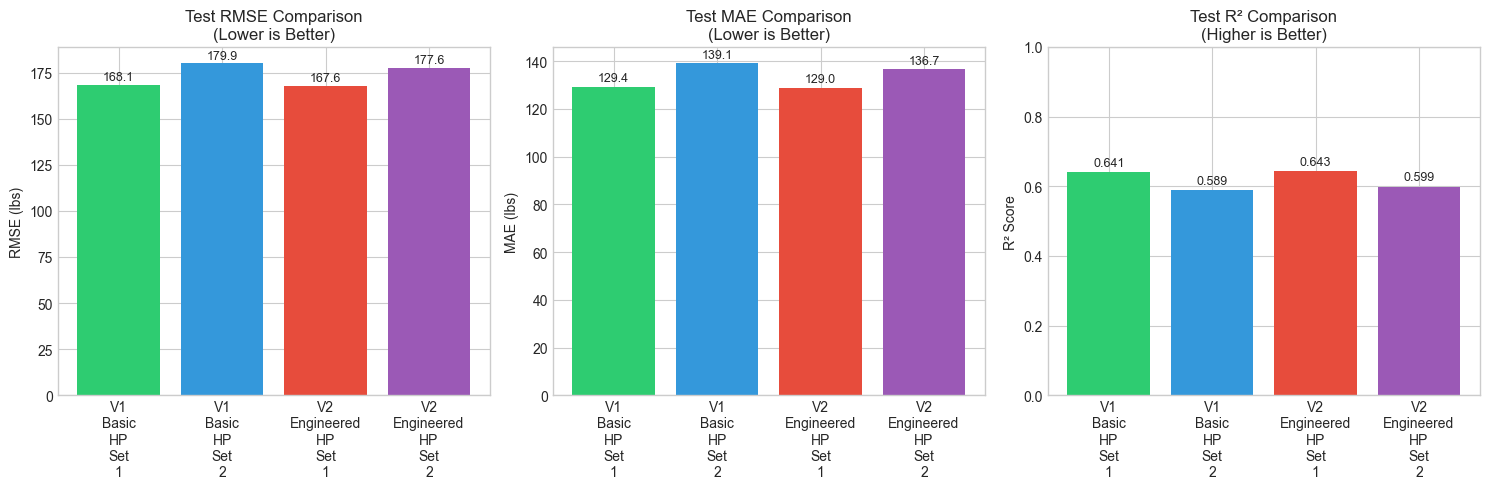

Saved: metrics_comparison.png


In [ ]:
fig, axes = plt.subplots(1, 3, figsize=(15, 5))

# RMSE comparison
ax1 = axes[0]
x = range(len(all_results))
bars = ax1.bar(x, [r['test_rmse'] for r in all_results], color=colors)
ax1.set_xticks(x)
ax1.set_xticklabels([r['run_name'].replace('RF_', '').replace('_', '\n') for r in all_results], rotation=0)
ax1.set_ylabel('RMSE (lbs)')
ax1.set_title('Test RMSE Comparison\n(Lower is Better)', fontsize=12)
for bar, val in zip(bars, [r['test_rmse'] for r in all_results]):
    ax1.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 1, f'{val:.1f}', 
             ha='center', va='bottom', fontsize=9)

# MAE comparison
ax2 = axes[1]
bars = ax2.bar(x, [r['test_mae'] for r in all_results], color=colors)
ax2.set_xticks(x)
ax2.set_xticklabels([r['run_name'].replace('RF_', '').replace('_', '\n') for r in all_results], rotation=0)
ax2.set_ylabel('MAE (lbs)')
ax2.set_title('Test MAE Comparison\n(Lower is Better)', fontsize=12)
for bar, val in zip(bars, [r['test_mae'] for r in all_results]):
    ax2.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 1, f'{val:.1f}', 
             ha='center', va='bottom', fontsize=9)

# R2 comparison
ax3 = axes[2]
bars = ax3.bar(x, [r['test_r2'] for r in all_results], color=colors)
ax3.set_xticks(x)
ax3.set_xticklabels([r['run_name'].replace('RF_', '').replace('_', '\n') for r in all_results], rotation=0)
ax3.set_ylabel('R² Score')
ax3.set_title('Test R² Comparison\n(Higher is Better)', fontsize=12)
ax3.set_ylim(0, 1)
for bar, val in zip(bars, [r['test_r2'] for r in all_results]):
    ax3.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.01, f'{val:.3f}', 
             ha='center', va='bottom', fontsize=9)

plt.tight_layout()
plt.savefig('metrics_comparison.png', dpi=150, bbox_inches='tight')
plt.show()
print("Saved: metrics_comparison.png")

Again, we see the results I highlighted earlier, this time visually. The first set of hyperparameters outperformed the second regardless of feature set. Meanwhile, the difference between the feature sets are minimal.

## 6.2 Actual vs Predicted Scatter Plots

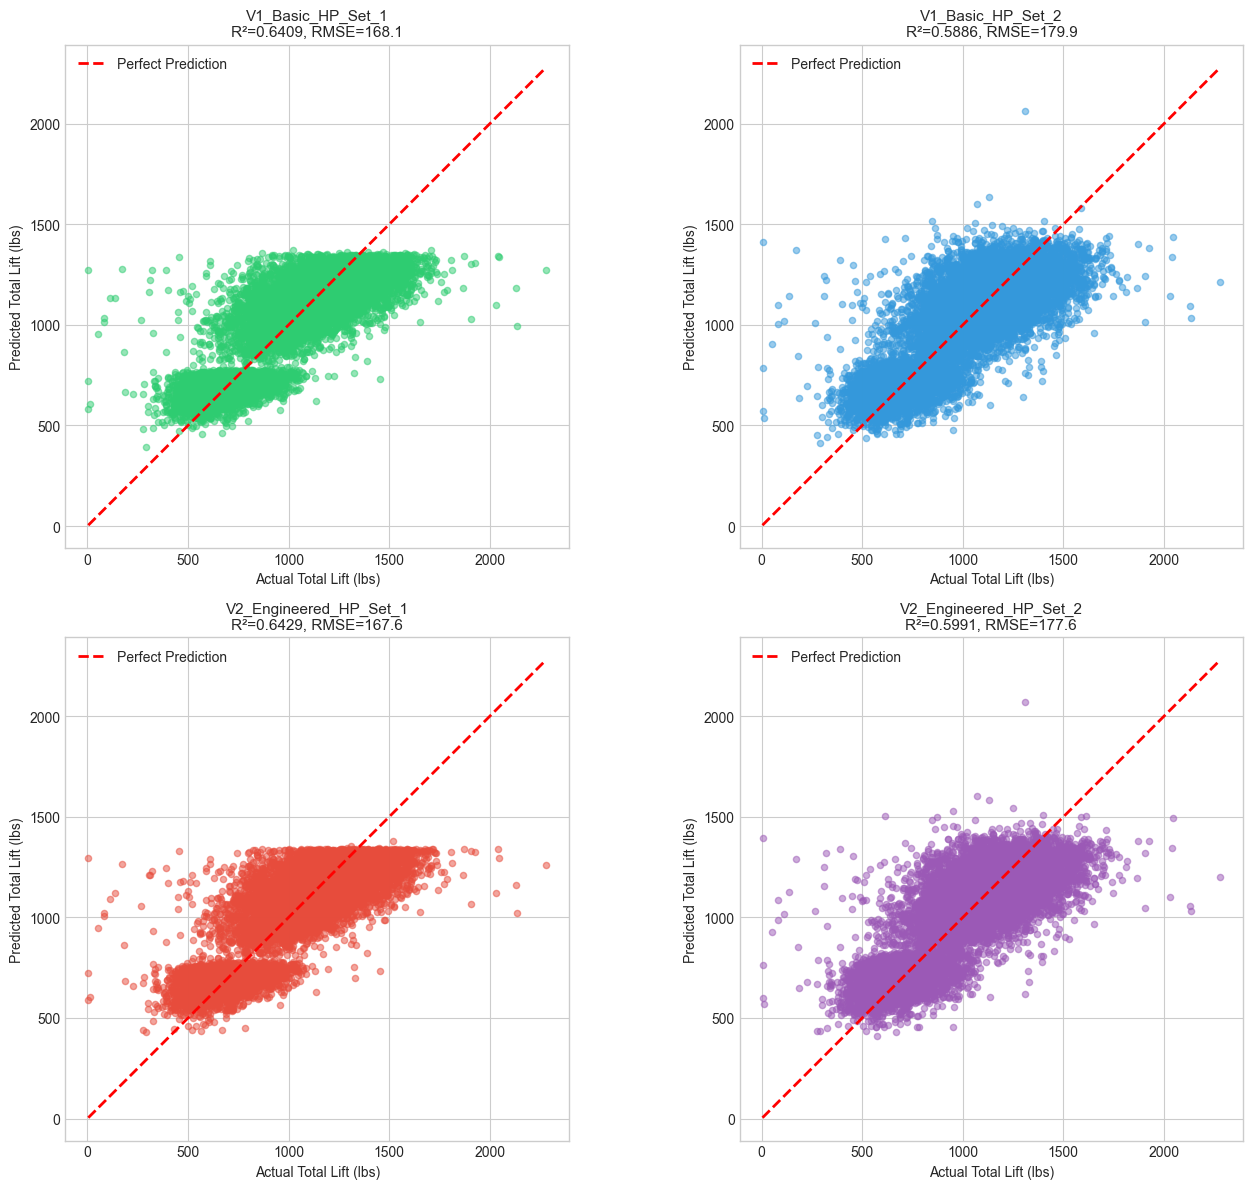

Saved: actual_vs_predicted.png


In [ ]:
fig, axes = plt.subplots(2, 2, figsize=(14, 12))
axes = axes.flatten()

for idx, result in enumerate(all_results):
    ax = axes[idx]
    y_test = result['y_test']
    y_pred = result['y_pred']
    
    # Scatter plot
    ax.scatter(y_test, y_pred, alpha=0.5, c=colors[idx], s=20)
    
    # Perfect prediction line
    min_val = min(y_test.min(), y_pred.min())
    max_val = max(y_test.max(), y_pred.max())
    ax.plot([min_val, max_val], [min_val, max_val], 'r--', lw=2, label='Perfect Prediction')
    
    ax.set_xlabel('Actual Total Lift (lbs)', fontsize=10)
    ax.set_ylabel('Predicted Total Lift (lbs)', fontsize=10)
    ax.set_title(f"{result['run_name'].replace('RF_', '')}\nR²={result['test_r2']:.4f}, RMSE={result['test_rmse']:.1f}", fontsize=11)
    ax.legend(loc='upper left')
    ax.set_aspect('equal', adjustable='box')

plt.tight_layout()
plt.savefig('actual_vs_predicted.png', dpi=150, bbox_inches='tight')
plt.show()
print("Saved: actual_vs_predicted.png")

One thing that is interesting in these residuals is that the first hyperparameter set appears to have learned what the "practical" maximum total lift should be compared the second hyperparameter set which did not do this. This may explain some of the reason that the first hyperparameter set outperformed the second set.

## 6.3 Feature Importance Comparison

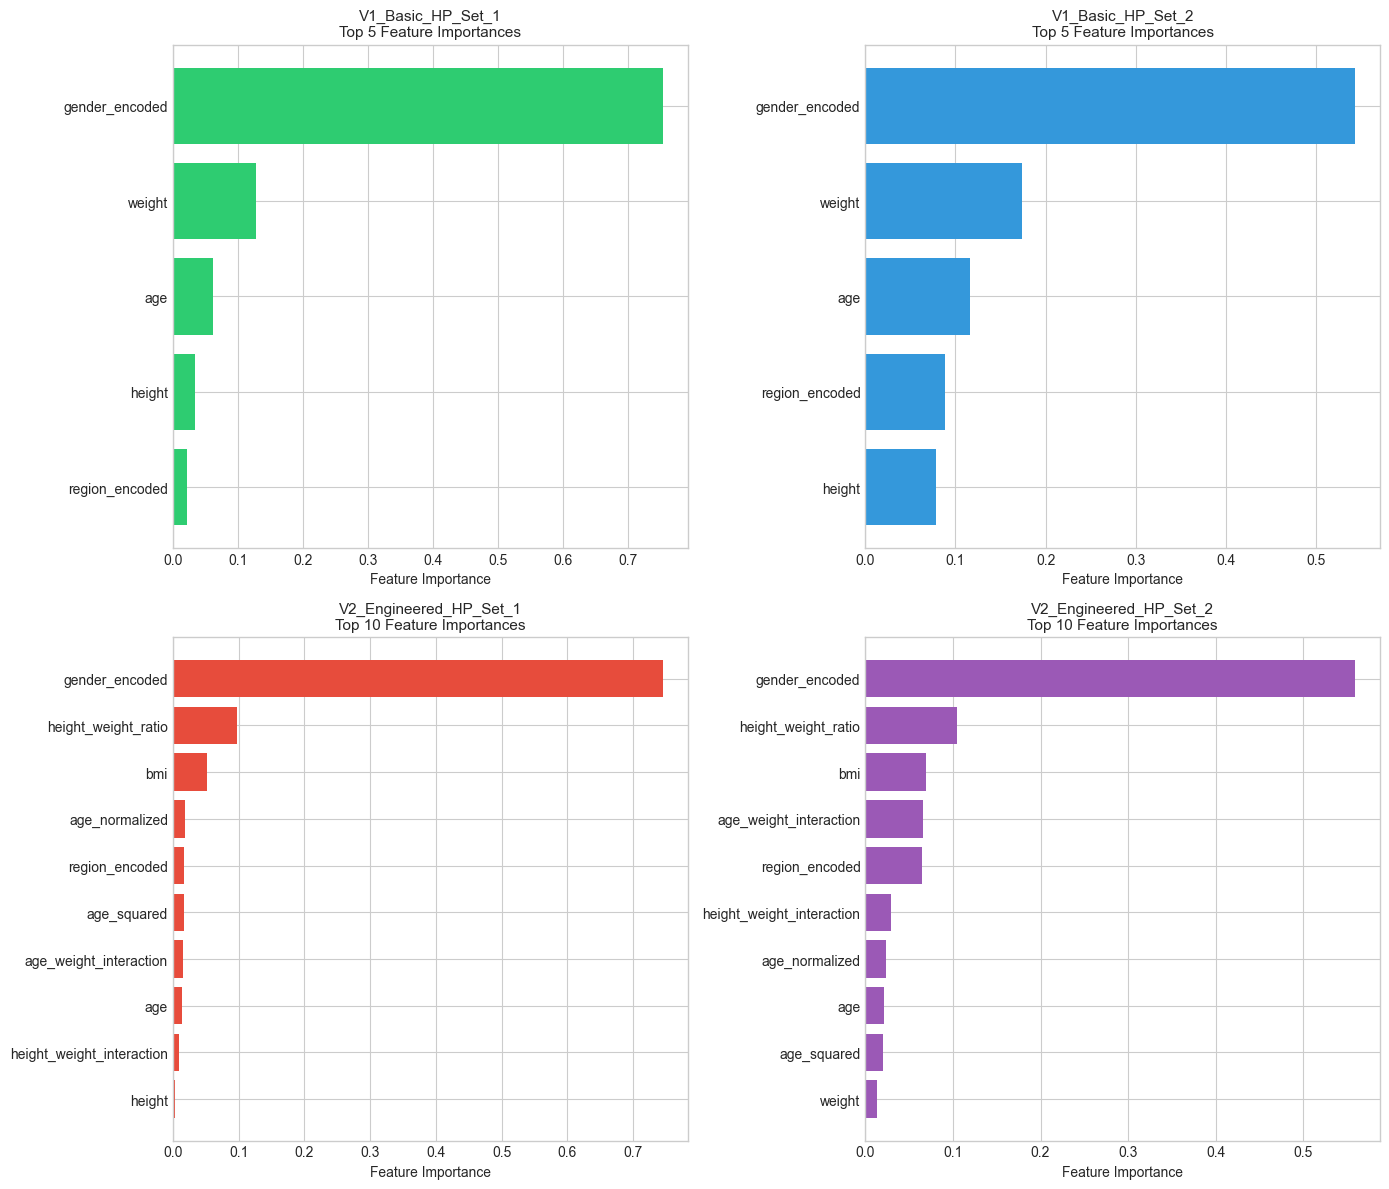

Saved: feature_importance.png


In [ ]:
fig, axes = plt.subplots(2, 2, figsize=(14, 12))
axes = axes.flatten()

for idx, result in enumerate(all_results):
    ax = axes[idx]
    model = result['model']
    feature_names = result['feature_cols']
    
    # Get feature importances
    importances = model.feature_importances_
    indices = np.argsort(importances)[::-1]
    
    # Plot top 10 features
    top_n = min(10, len(feature_names))
    top_indices = indices[:top_n]
    
    ax.barh(range(top_n), importances[top_indices][::-1], color=colors[idx])
    ax.set_yticks(range(top_n))
    ax.set_yticklabels([feature_names[i] for i in top_indices[::-1]])
    ax.set_xlabel('Feature Importance', fontsize=10)
    ax.set_title(f"{result['run_name'].replace('RF_', '')}\nTop {top_n} Feature Importances", fontsize=11)

plt.tight_layout()
plt.savefig('feature_importance.png', dpi=150, bbox_inches='tight')
plt.show()
print("Saved: feature_importance.png")

Across the board, gender was the most important feature in both models. It does appear that the additional features such as height_weight_ratio and bmi played an important role in the second feature set.

## 6.4 Train vs Test Performance (Overfitting Check)

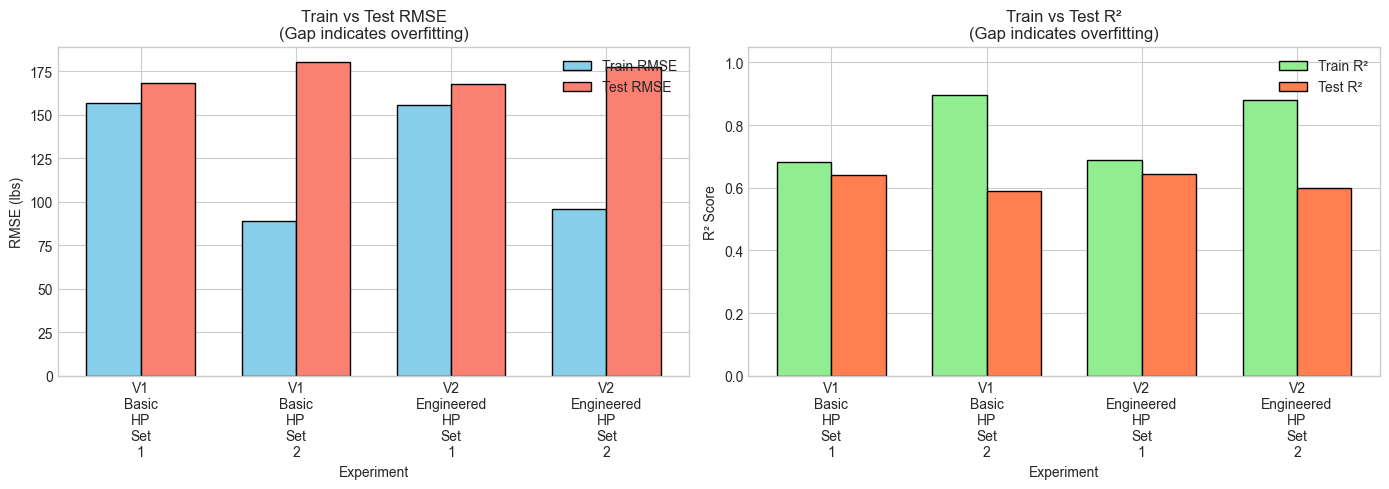

Saved: train_vs_test.png


In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# RMSE comparison
ax1 = axes[0]
x = np.arange(len(all_results))
width = 0.35

train_rmse = [r['train_rmse'] for r in all_results]
test_rmse = [r['test_rmse'] for r in all_results]

bars1 = ax1.bar(x - width/2, train_rmse, width, label='Train RMSE', color='skyblue', edgecolor='black')
bars2 = ax1.bar(x + width/2, test_rmse, width, label='Test RMSE', color='salmon', edgecolor='black')

ax1.set_xlabel('Experiment')
ax1.set_ylabel('RMSE (lbs)')
ax1.set_title('Train vs Test RMSE\n(Gap indicates overfitting)', fontsize=12)
ax1.set_xticks(x)
ax1.set_xticklabels([r['run_name'].replace('RF_', '').replace('_', '\n') for r in all_results])
ax1.legend()

# R2 comparison
ax2 = axes[1]
train_r2 = [r['train_r2'] for r in all_results]
test_r2 = [r['test_r2'] for r in all_results]

bars1 = ax2.bar(x - width/2, train_r2, width, label='Train R²', color='lightgreen', edgecolor='black')
bars2 = ax2.bar(x + width/2, test_r2, width, label='Test R²', color='coral', edgecolor='black')

ax2.set_xlabel('Experiment')
ax2.set_ylabel('R² Score')
ax2.set_title('Train vs Test R²\n(Gap indicates overfitting)', fontsize=12)
ax2.set_xticks(x)
ax2.set_xticklabels([r['run_name'].replace('RF_', '').replace('_', '\n') for r in all_results])
ax2.legend()
ax2.set_ylim(0, 1.05)

plt.tight_layout()
plt.savefig('train_vs_test.png', dpi=150, bbox_inches='tight')
plt.show()
print("Saved: train_vs_test.png")

Here, we see a massive generalization gap in the second hyperparameter set. This signals overfitting which happened in the second hyperparameter set. Some of this overfitting comes as the second hyperparameter set has a greater tree depth as well as less regularization in terms of the minimum sample splits and minimum sample leaves, which are less than the first hyperparameter set. Based on this, these results are expected.

---
# Part 7: Carbon Emissions

CodeCarbon is a Python library that estimates the carbon emissions of machine learning workloads based on hardware usage, runtime, and regional energy sources. It provides an easy way to track and compare the environmental impact of different experiments.

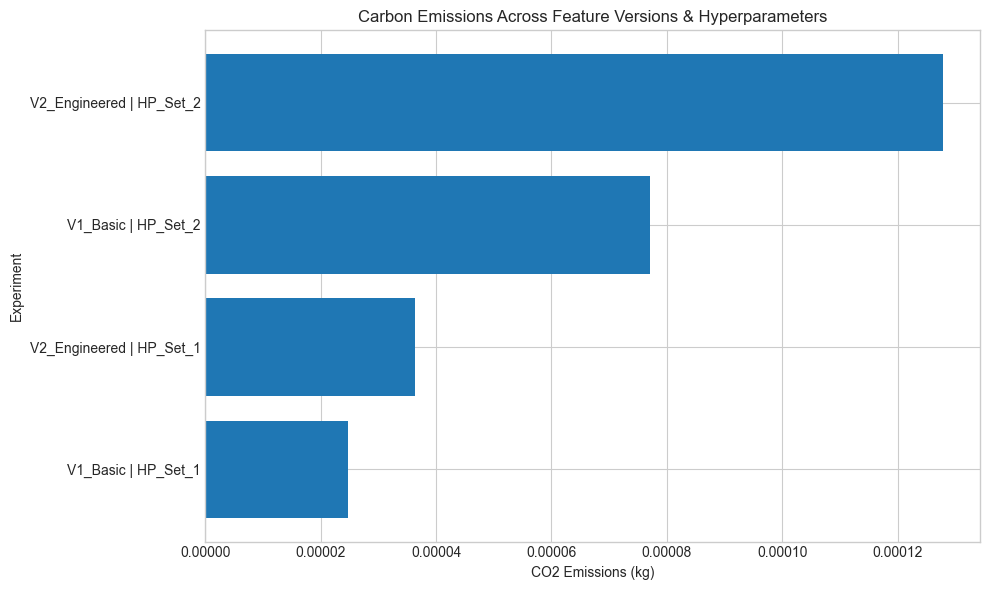

In [89]:
import mlflow
import pandas as pd
import matplotlib.pyplot as plt

EXPERIMENT_NAME = "Athlete_TotalLift_Prediction"

# Get experiment
experiment = mlflow.get_experiment_by_name(EXPERIMENT_NAME)

# Load all runs
runs_df = mlflow.search_runs(experiment_ids=[experiment.experiment_id])

# Select relevant columns
df = runs_df[[
    "tags.feature_version",
    "tags.hyperparameter_set",
    "metrics.co2_emissions_kg",
    "metrics.test_r2",
    "metrics.test_rmse"
]].dropna()

# Create readable experiment labels
df["experiment"] = (
    df["tags.feature_version"] + " | " + df["tags.hyperparameter_set"]
)

# Sort by emissions
df = df.sort_values("metrics.co2_emissions_kg")

# ---------------------------------------------------
# 📈 Plot 1: Emissions Comparison
# ---------------------------------------------------
plt.figure(figsize=(10, 6))
plt.barh(df["experiment"], df["metrics.co2_emissions_kg"])

plt.xlabel("CO2 Emissions (kg)")
plt.ylabel("Experiment")
plt.title("Carbon Emissions Across Feature Versions & Hyperparameters")

plt.tight_layout()
plt.show()

It appears that the second hyperparameter set emitted more carbon dioxide than the first hyperparameter set. This is likely because of the higher number of estimators and the deeper trees. Moreover, it appears that the additional features in the second feature set does have an impact on the amout on carbon dioxide emissions as it adds additional computational cost.

---
# Part 8: Summary, Conclusions, & Reflection

This project implemented an end-to-end ML pipeline using Feast for feature versioning and MLflow for experiment tracking, enabling consistent data usage and reproducible model development. By comparing multiple feature sets and hyperparameter configurations, the pipeline highlighted tradeoffs between model performance, generalization, and computational cost. Overall, integrating feature stores with experiment tracking provides an easy way to keep track of the features used, the experiments ran, and ultimately serve the best combination of features, hyperparameter, and model.